## 1. Environment setup and output folders

The next cell imports the required libraries, mounts Google Drive if the notebook is executed in Colab, and creates standard output folders for figures, tables, and summary files.


In [2]:
import os
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

SEED = 42
np.random.seed(SEED)

PROJECT_NAME = "QSFE"
LOCAL_BASE = Path("./outputs") / PROJECT_NAME

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive", force_remount=True)
    BASE_DIR = Path("/content/drive/MyDrive/Outputs") / PROJECT_NAME
else:
    BASE_DIR = LOCAL_BASE

FIG_DIR = BASE_DIR / "figures"
TAB_DIR = BASE_DIR / "tables"
OTH_DIR = BASE_DIR / "others"

for p in [FIG_DIR, TAB_DIR, OTH_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Base directory : {BASE_DIR.resolve()}")
print(f"Figures dir    : {FIG_DIR.resolve()}")
print(f"Tables dir     : {TAB_DIR.resolve()}")
print(f"Others dir     : {OTH_DIR.resolve()}")


Base directory : F:\MBZUAI UAE\12-Elsevier-Cryptography\GitHub\Free-Energy-Perspective-on-Quantum-Cryptographic-Security\outputs\QSFE
Figures dir    : F:\MBZUAI UAE\12-Elsevier-Cryptography\GitHub\Free-Energy-Perspective-on-Quantum-Cryptographic-Security\outputs\QSFE\figures
Tables dir     : F:\MBZUAI UAE\12-Elsevier-Cryptography\GitHub\Free-Energy-Perspective-on-Quantum-Cryptographic-Security\outputs\QSFE\tables
Others dir     : F:\MBZUAI UAE\12-Elsevier-Cryptography\GitHub\Free-Energy-Perspective-on-Quantum-Cryptographic-Security\outputs\QSFE\others


## 2. Variational design and simulation space

The next cell defines the operating grids and the weights of the discrete variational model. The weights preserve continuity with the earlier prototypes while enabling curvature-sensitive action analysis.


In [3]:
# Simulation grids
n_noise = 31
n_phase = 21
n_attack = 21

depolarizing_grid = np.linspace(0.0, 0.18, n_noise)
phase_grid = np.linspace(0.0, 0.20, n_phase)
attack_grid = np.linspace(0.0, 1.00, n_attack)

BB84_QBER_THRESHOLD = 0.11
EPS = 1e-6

# Lagrangian / instability weights
ALPHA = 0.35   # entropy
BETA  = 0.20   # channel degradation
GAMMA = 0.25   # adversarial likelihood
DELTA = 0.20   # secure capacity
ETA_VAR   = 0.35   # variance contribution
ZETA_SLOPE = 0.30  # slope contribution
THETA_CURV = 0.50  # curvature contribution

print("Grid sizes:", len(depolarizing_grid), len(phase_grid), len(attack_grid))
print("Weights:", {
    "ALPHA": ALPHA, "BETA": BETA, "GAMMA": GAMMA, "DELTA": DELTA,
    "ETA_VAR": ETA_VAR, "ZETA_SLOPE": ZETA_SLOPE, "THETA_CURV": THETA_CURV
})


Grid sizes: 31 21 21
Weights: {'ALPHA': 0.35, 'BETA': 0.2, 'GAMMA': 0.25, 'DELTA': 0.2, 'ETA_VAR': 0.35, 'ZETA_SLOPE': 0.3, 'THETA_CURV': 0.5}


## 3. Core scientific functions

The next cell defines the key quantities used in the notebook:
- binary entropy,
- BB84-inspired QBER and key-rate proxies,
- channel-loss and AI-assisted attack terms,
- the discrete security Lagrangian,
- curvature-safe differential utilities,
- action accumulation,
- and inflection-based warning detection.


In [4]:
def clip01(x):
    return np.clip(x, 0.0, 1.0)

def binary_entropy(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def qber_proxy(depolarizing_noise, phase_noise, attack_intensity):
    q = (
        0.55 * depolarizing_noise
        + 0.18 * phase_noise
        + 0.10 * depolarizing_noise * phase_noise
        + 0.07 * attack_intensity
        + 0.12 * attack_intensity * depolarizing_noise
        + 0.06 * attack_intensity * phase_noise
    )
    return clip01(q)

def key_rate_proxy(qber, efficiency_factor=1.0):
    h = binary_entropy(qber)
    return np.maximum(0.0, efficiency_factor * (1.0 - 2.0 * h))

def channel_loss_proxy(depolarizing_noise, phase_noise):
    loss = 0.65 * depolarizing_noise + 0.35 * phase_noise
    max_loss = 0.65 * depolarizing_grid.max() + 0.35 * phase_grid.max()
    return clip01(loss / max_loss)

def normalize_series(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    if np.all(np.isnan(x)):
        return np.zeros_like(x, dtype=float)
    mn = np.nanmin(x)
    mx = np.nanmax(x)
    if mx - mn < 1e-12:
        return np.zeros_like(x, dtype=float)
    y = (x - mn) / (mx - mn)
    return np.nan_to_num(y, nan=0.0, posinf=1.0, neginf=0.0)

def rolling_window_variance(arr, window=5):
    arr = np.asarray(arr, dtype=float)
    out = np.zeros_like(arr)
    half = window // 2
    for i in range(len(arr)):
        lo = max(0, i - half)
        hi = min(len(arr), i + half + 1)
        out[i] = np.var(arr[lo:hi])
    return out

def backward_negative_slope(arr, xgrid):
    arr = np.asarray(arr, dtype=float)
    xgrid = np.asarray(xgrid, dtype=float)
    out = np.zeros_like(arr)
    for i in range(1, len(arr)):
        dx = xgrid[i] - xgrid[i - 1]
        dx = dx if abs(dx) > EPS else EPS
        slope = (arr[i] - arr[i - 1]) / dx
        out[i] = max(0.0, -slope)
    return out

def safe_gradient(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, 0.0)
    for i in range(1, len(x)):
        if abs(x[i] - x[i-1]) < EPS:
            x[i] = x[i-1] + EPS
    if len(x) > 1 and abs(x[1] - x[0]) < EPS:
        x[0] = x[0] - EPS
    return np.gradient(y, x, edge_order=1)

def precritical_gate(qber_arr, key_arr, threshold=BB84_QBER_THRESHOLD):
    qber_arr = np.asarray(qber_arr, dtype=float)
    key_arr = np.asarray(key_arr, dtype=float)
    return ((qber_arr >= 0.70 * threshold) & (key_arr > 0)).astype(float)

def security_lagrangian(entropy_term, channel_term, attack_term, capacity_term, instability_term=0.0):
    return (
        ALPHA * entropy_term
        + BETA * channel_term
        + GAMMA * attack_term
        - DELTA * capacity_term
        + instability_term
    )

def accumulate_action(lagrangian, path_coordinate):
    lagrangian = np.asarray(lagrangian, dtype=float)
    path_coordinate = np.asarray(path_coordinate, dtype=float)
    delta = np.diff(path_coordinate, prepend=path_coordinate[0])
    delta = np.where(np.abs(delta) < EPS, EPS, delta)
    increments = lagrangian * delta
    action = np.cumsum(increments)
    return delta, increments, action

def detect_inflection_idx(arr):
    arr = np.asarray(arr, dtype=float)
    second = np.gradient(np.gradient(arr))
    return int(np.argmax(second))

def anticipation_pct(warning_coord, collapse_coord):
    if warning_coord is None or collapse_coord is None or collapse_coord <= 0:
        return np.nan
    return 100.0 * (collapse_coord - warning_coord) / collapse_coord


## 4. Global state-space generation and AI-assisted adversarial likelihood

The next cell generates the full state space and derives an AI-assisted attack term using unsupervised anomaly detection. This gives a consistent adversarial signal that can be used inside the security Lagrangian.


In [5]:
rows = []
for d in depolarizing_grid:
    for ph in phase_grid:
        for a in attack_grid:
            q = qber_proxy(d, ph, a)
            h = binary_entropy(q)
            k = key_rate_proxy(q)
            loss = channel_loss_proxy(d, ph)
            rows.append([d, ph, a, q, h, k, loss])

df = pd.DataFrame(rows, columns=[
    "depolarizing_noise", "phase_noise", "attack_intensity",
    "qber", "entropy", "key_rate", "channel_loss"
])

iso_features = df[["depolarizing_noise", "phase_noise", "qber", "entropy", "key_rate", "channel_loss"]].copy()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(iso_features)

iso = IsolationForest(n_estimators=250, contamination=0.15, random_state=SEED)
iso.fit(X_scaled)

raw_score = -iso.score_samples(X_scaled)
raw_score = normalize_series(raw_score)

df["ai_attack_likelihood"] = clip01(0.55 * df["attack_intensity"] + 0.45 * raw_score)
df["lagrangian_base"] = security_lagrangian(
    entropy_term=df["entropy"].values,
    channel_term=df["channel_loss"].values,
    attack_term=df["ai_attack_likelihood"].values,
    capacity_term=df["key_rate"].values,
    instability_term=0.0
)
df["collapse"] = (df["key_rate"] <= 1e-8).astype(int)

summary_stats = df[[
    "depolarizing_noise", "phase_noise", "attack_intensity",
    "qber", "entropy", "key_rate", "channel_loss",
    "ai_attack_likelihood", "lagrangian_base"
]].describe().T

summary_stats.to_csv(TAB_DIR / "table_summary_statistics.csv")

display(summary_stats)
print("Global state-space shape:", df.shape)
print("Collapse fraction:", float(df["collapse"].mean()))


,count,mean,std,min,25%,50%,75%,max
depolarizing_noise,13671.0,0.090000,0.053668,0.000000e+00,0.042000,0.090000,0.138000,0.180000
phase_noise,13671.0,0.100000,0.060555,0.000000e+00,0.050000,0.100000,0.150000,0.200000
attack_intensity,13671.0,0.500000,0.302776,0.000000e+00,0.250000,0.500000,0.750000,1.000000
qber,13671.0,0.111800,0.044484,0.000000e+00,0.079060,0.110220,0.142993,0.242200
entropy,13671.0,0.490206,0.136818,4.130580e-11,0.398858,0.500579,0.592024,0.798680
key_rate,13671.0,0.120584,0.177187,0.000000e+00,0.000000,0.000000,0.202283,1.000000
channel_loss,13671.0,0.500000,0.218277,0.000000e+00,0.336898,0.500000,0.663102,1.000000
ai_attack_likelihood,13671.0,0.389050,0.164455,8.043269e-02,0.251176,0.369455,0.514788,0.925060
lagrangian_base,13671.0,0.344718,0.132275,-8.750000e-02,0.256648,0.358415,0.435603,0.710803


Global state-space shape: (13671, 10)
Collapse fraction: 0.5015726720795846


## 5. Trajectory constructors

The next cell defines several admissible security trajectories. Comparing multiple paths through the same state space is essential for the variational interpretation because collapse is treated as a trajectory-dependent event rather than a pointwise threshold crossing.


In [6]:
def build_trajectory(name):
    rows = []

    if name == "physical_noise_dominant":
        phase = 0.06
        attack = 0.30
        for d in depolarizing_grid:
            rows.append((d, phase, attack))

    elif name == "attack_dominant":
        phase = 0.06
        dep = 0.08
        for a in attack_grid:
            rows.append((dep, phase, a))

    elif name == "mixed_escalation":
        for i, d in enumerate(depolarizing_grid):
            a = attack_grid[min(len(attack_grid)-1, int(i * (len(attack_grid)-1) / max(1, len(depolarizing_grid)-1)))]
            phase = 0.04 + 0.04 * (d / max(depolarizing_grid.max(), EPS))
            rows.append((d, phase, a))

    elif name == "phase_sensitive":
        dep = 0.08
        attack = 0.25
        for ph in phase_grid:
            rows.append((dep, ph, attack))

    elif name == "curvature_probe":
        for i, d in enumerate(depolarizing_grid):
            phase = 0.03 + 0.08 * (d / max(depolarizing_grid.max(), EPS))**2
            attack = 0.10 + 0.55 * np.sin((i / max(1, len(depolarizing_grid)-1)) * np.pi / 2.0)
            rows.append((d, phase, attack))

    else:
        raise ValueError(f"Unknown trajectory name: {name}")

    return pd.DataFrame(rows, columns=["depolarizing_noise", "phase_noise", "attack_intensity"])

trajectory_names = [
    "physical_noise_dominant",
    "attack_dominant",
    "mixed_escalation",
    "phase_sensitive",
    "curvature_probe"
]

trajectory_names


['physical_noise_dominant',
 'attack_dominant',
 'mixed_escalation',
 'phase_sensitive',
 'curvature_probe']

## 6. Trajectory evaluation with curvature-enhanced instability

The next cell evaluates each trajectory and computes:
- entropy,
- key rate,
- channel loss,
- AI-assisted attack likelihood,
- local variance of key rate,
- negative key-rate slope,
- curvature of the baseline Lagrangian,
- curvature-enhanced critical instability potential,
- baseline and predictive Lagrangians,
- action and normalized action,
- and action acceleration.


In [7]:
all_trajs = []

for name in trajectory_names:
    traj = build_trajectory(name).copy()

    traj["qber"] = traj.apply(lambda r: qber_proxy(r["depolarizing_noise"], r["phase_noise"], r["attack_intensity"]), axis=1)
    traj["entropy"] = traj["qber"].apply(binary_entropy)
    traj["key_rate"] = traj["qber"].apply(key_rate_proxy)
    traj["channel_loss"] = traj.apply(lambda r: channel_loss_proxy(r["depolarizing_noise"], r["phase_noise"]), axis=1)

    local_attack = 0.55 * traj["attack_intensity"].values + 0.45 * normalize_series(traj["qber"].values)
    traj["ai_attack_likelihood"] = clip01(local_attack)

    if name == "attack_dominant":
        active_coord = traj["attack_intensity"].values
    elif name == "phase_sensitive":
        active_coord = traj["phase_noise"].values
    else:
        active_coord = traj["depolarizing_noise"].values

    active_coord = np.asarray(active_coord, dtype=float)
    for i in range(1, len(active_coord)):
        if abs(active_coord[i] - active_coord[i-1]) < EPS:
            active_coord[i] = active_coord[i-1] + EPS
    traj["path_coordinate"] = active_coord

    traj["lagrangian_base"] = security_lagrangian(
        entropy_term=traj["entropy"].values,
        channel_term=traj["channel_loss"].values,
        attack_term=traj["ai_attack_likelihood"].values,
        capacity_term=traj["key_rate"].values,
        instability_term=0.0
    )

    traj["var_k_raw"] = rolling_window_variance(traj["key_rate"].values, window=5)
    traj["neg_slope_raw"] = backward_negative_slope(traj["key_rate"].values, traj["path_coordinate"].values)

    base_curvature = safe_gradient(
        safe_gradient(traj["lagrangian_base"].values, traj["path_coordinate"].values),
        traj["path_coordinate"].values
    )

    traj["var_k_norm"] = normalize_series(traj["var_k_raw"].values)
    traj["neg_slope_norm"] = normalize_series(traj["neg_slope_raw"].values)
    traj["curvature_norm"] = normalize_series(np.abs(base_curvature))
    traj["precritical_gate"] = precritical_gate(traj["qber"].values, traj["key_rate"].values)

    traj["critical_instability_potential"] = traj["precritical_gate"] * (
        ETA_VAR * traj["var_k_norm"]
        + ZETA_SLOPE * traj["neg_slope_norm"]
        + THETA_CURV * traj["curvature_norm"]
    )

    traj["lagrangian_predictive"] = security_lagrangian(
        entropy_term=traj["entropy"].values,
        channel_term=traj["channel_loss"].values,
        attack_term=traj["ai_attack_likelihood"].values,
        capacity_term=traj["key_rate"].values,
        instability_term=traj["critical_instability_potential"].values
    )

    delta_coord, pred_incr, action_pred = accumulate_action(traj["lagrangian_predictive"].values, traj["path_coordinate"].values)
    _, base_incr, action_base = accumulate_action(traj["lagrangian_base"].values, traj["path_coordinate"].values)

    traj["delta_coord"] = delta_coord
    traj["action_base_increment"] = base_incr
    traj["action_predictive_increment"] = pred_incr
    traj["action_base"] = action_base
    traj["action_predictive"] = action_pred
    traj["normalized_action"] = traj["action_predictive"] / (1.0 + np.abs(traj["path_coordinate"]))
    traj["action_velocity"] = safe_gradient(traj["action_predictive"].values, traj["path_coordinate"].values)
    traj["action_acceleration"] = safe_gradient(traj["action_velocity"].values, traj["path_coordinate"].values)
    traj["collapse"] = (traj["key_rate"] <= 1e-8).astype(int)
    traj["trajectory_name"] = name

    all_trajs.append(traj)

traj_df = pd.concat(all_trajs, ignore_index=True)
traj_df.to_csv(TAB_DIR / "table_all_trajectories.csv", index=False)

display(traj_df.head())
print("Trajectory table shape:", traj_df.shape)


,depolarizing_noise,phase_noise,attack_intensity,qber,entropy,key_rate,channel_loss,ai_attack_likelihood,path_coordinate,lagrangian_base,...,delta_coord,action_base_increment,action_predictive_increment,action_base,action_predictive,normalized_action,action_velocity,action_acceleration,collapse,trajectory_name
0,0.000,0.06,0.3,0.032880,0.208635,0.582729,0.112299,0.165,0.000,0.020186,...,0.000001,2.018644e-08,2.018644e-08,2.018644e-08,2.018644e-08,2.018644e-08,0.040896,1.693348,0,physical_noise_dominant
1,0.006,0.06,0.3,0.036432,0.225687,0.548626,0.133155,0.180,0.006,0.040896,...,0.006000,2.453765e-04,2.453765e-04,2.453967e-04,2.453967e-04,2.439331e-04,0.051056,2.525184,0,physical_noise_dominant
2,0.012,0.06,0.3,0.039984,0.242219,0.515562,0.154011,0.195,0.012,0.061216,...,0.006000,3.672975e-04,3.672975e-04,6.126943e-04,6.126943e-04,6.054291e-04,0.071198,3.328509,0,physical_noise_dominant
3,0.018,0.06,0.3,0.043536,0.258276,0.483448,0.174866,0.210,0.018,0.081180,...,0.006000,4.870820e-04,4.870820e-04,1.099776e-03,1.099776e-03,1.080330e-03,0.090998,3.273634,0,physical_noise_dominant
4,0.024,0.06,0.3,0.047088,0.273896,0.452208,0.195722,0.225,0.024,0.100816,...,0.006000,6.048973e-04,6.048973e-04,1.704674e-03,1.704674e-03,1.664720e-03,0.110482,3.222742,0,physical_noise_dominant


Trajectory table shape: (135, 28)


## 7. Trajectory summary table

The next cell summarizes the trajectory behavior in terms of collapse coordinate, action at collapse, final action, maximum acceleration, and maximum instability.


In [8]:
summary_rows = []
for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name].copy().reset_index(drop=True)

    collapse_indices = np.where(sub["collapse"].values == 1)[0]
    has_collapse = len(collapse_indices) > 0
    if has_collapse:
        cidx = int(collapse_indices[0])
        collapse_coord = float(sub.loc[cidx, "path_coordinate"])
        action_at_collapse = float(sub.loc[cidx, "action_predictive"])
    else:
        collapse_coord = np.nan
        action_at_collapse = np.nan

    summary_rows.append([
        name,
        int(has_collapse),
        collapse_coord,
        action_at_collapse,
        float(sub["action_predictive"].iloc[-1]),
        float(np.max(sub["critical_instability_potential"])),
        float(np.max(sub["action_acceleration"]))
    ])

trajectory_summary = pd.DataFrame(summary_rows, columns=[
    "trajectory_name",
    "has_collapse",
    "collapse_coordinate",
    "action_at_collapse",
    "final_predictive_action",
    "max_instability_potential",
    "max_action_acceleration"
])

trajectory_summary.to_csv(TAB_DIR / "table_trajectory_summary.csv", index=False)
display(trajectory_summary)


,trajectory_name,has_collapse,collapse_coordinate,action_at_collapse,final_predictive_action,max_instability_potential,max_action_acceleration
0,physical_noise_dominant,1,0.132,0.056017,0.078369,0.666001,41.818206
1,attack_dominant,1,0.700,0.438441,0.585430,0.806681,6.334570
2,mixed_escalation,1,0.102,0.029500,0.072193,0.585518,47.701127
3,phase_sensitive,0,NaN,NaN,0.169951,0.986730,50.123979
4,curvature_probe,1,0.102,0.032389,0.073001,0.648519,38.408274


## 8. Plot: predictive Lagrangian profiles

The next cell compares the predictive security Lagrangian across admissible trajectories.


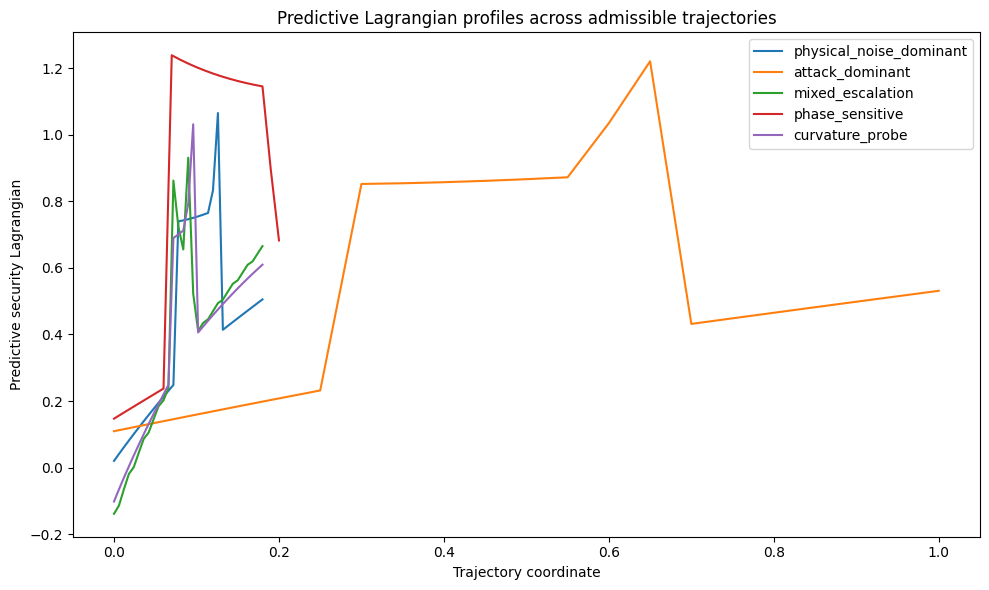

In [9]:
plt.figure(figsize=(10, 6))
for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name]
    plt.plot(sub["path_coordinate"], sub["lagrangian_predictive"], label=name)
plt.xlabel("Trajectory coordinate")
plt.ylabel("Predictive security Lagrangian")
plt.title("Predictive Lagrangian profiles across admissible trajectories")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_lagrangian_profiles.png", dpi=300)
plt.show()


## 9. Plot: action accumulation and normalized action

The next two cells visualize both the raw accumulated action and the normalized action used to compare trajectories of different effective lengths and scales.


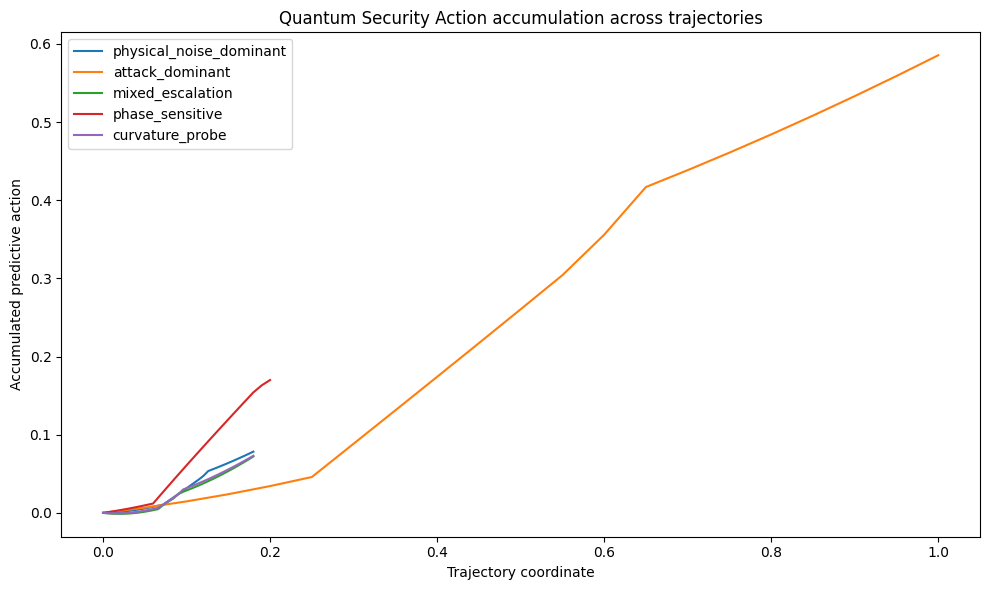

In [10]:
plt.figure(figsize=(10, 6))
for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name]
    plt.plot(sub["path_coordinate"], sub["action_predictive"], label=name)
plt.xlabel("Trajectory coordinate")
plt.ylabel("Accumulated predictive action")
plt.title("Quantum Security Action accumulation across trajectories")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_action_accumulation.png", dpi=300)
plt.show()


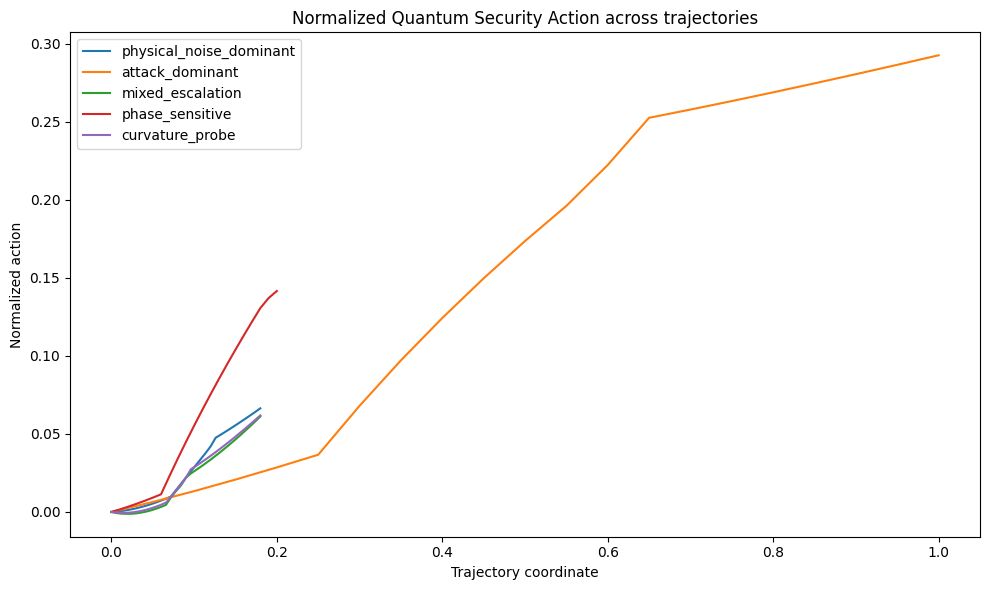

In [11]:
plt.figure(figsize=(10, 6))
for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name]
    plt.plot(sub["path_coordinate"], sub["normalized_action"], label=name)
plt.xlabel("Trajectory coordinate")
plt.ylabel("Normalized action")
plt.title("Normalized Quantum Security Action across trajectories")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_normalized_action.png", dpi=300)
plt.show()


## 10. Plot: action acceleration and curvature-enhanced instability

The next cell visualizes second-order dynamical behavior. These quantities are central to the upgraded theoretical argument because collapse is hypothesized to be preceded by curvature amplification and action acceleration spikes.


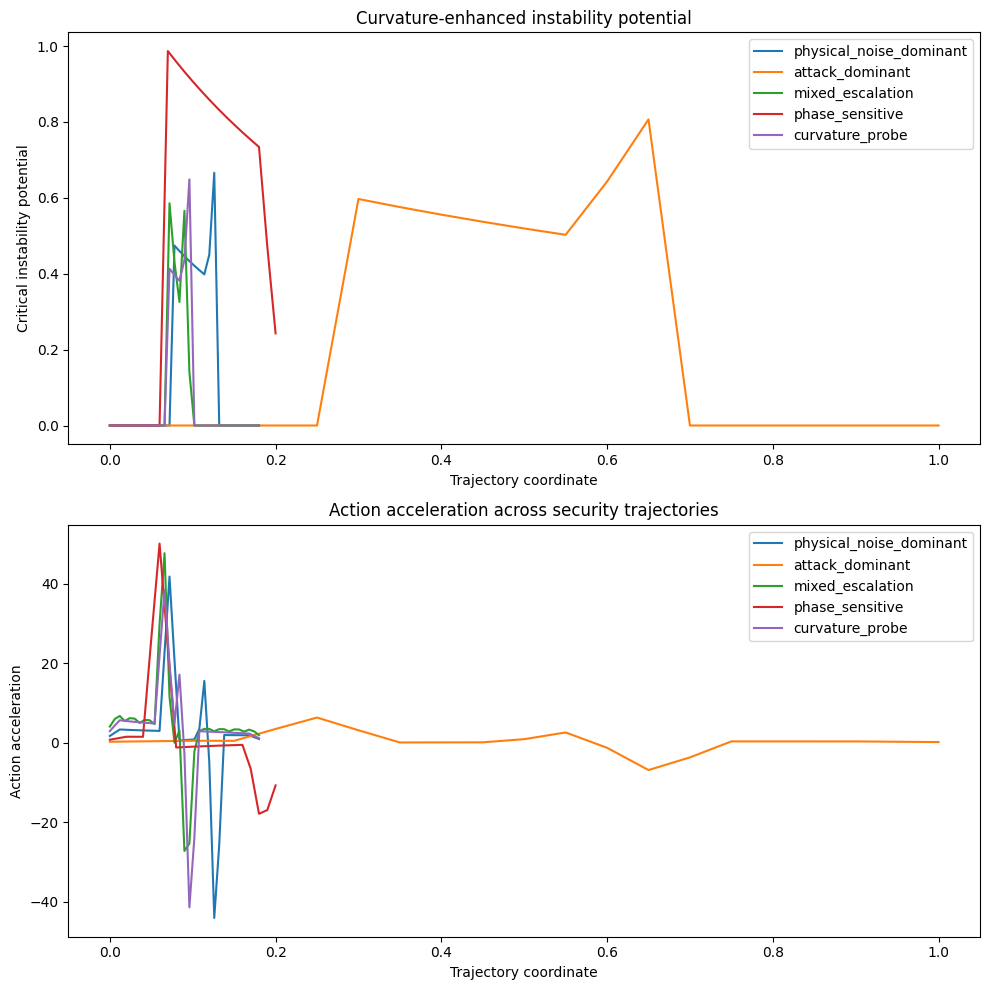

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name]
    axes[0].plot(sub["path_coordinate"], sub["critical_instability_potential"], label=name)
    axes[1].plot(sub["path_coordinate"], sub["action_acceleration"], label=name)

axes[0].set_xlabel("Trajectory coordinate")
axes[0].set_ylabel("Critical instability potential")
axes[0].set_title("Curvature-enhanced instability potential")
axes[0].legend()

axes[1].set_xlabel("Trajectory coordinate")
axes[1].set_ylabel("Action acceleration")
axes[1].set_title("Action acceleration across security trajectories")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_instability_and_action_acceleration.png", dpi=300)
plt.show()


## 11. Early-warning analysis

The next cell performs an inflection-based early-warning analysis. Instead of using only a fixed threshold on the action, the warning point is chosen from the strongest pre-collapse action-acceleration event, which is more consistent with the variational interpretation.


In [13]:
ew_rows = []

for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name].copy().reset_index(drop=True)

    collapse_indices = np.where(sub["collapse"].values == 1)[0]
    has_collapse = len(collapse_indices) > 0

    if has_collapse:
        cidx = int(collapse_indices[0])
        collapse_coord = float(sub.loc[cidx, "path_coordinate"])
        pre_sub = sub.iloc[:cidx].copy()

        if len(pre_sub) >= 3:
            inflection_idx = detect_inflection_idx(pre_sub["action_predictive"].values)
            accel_idx = int(np.argmax(pre_sub["action_acceleration"].values))
            # use the earlier of the two signals if both are meaningful
            warning_idx = min(inflection_idx, accel_idx)
            warning_coord = float(pre_sub.loc[warning_idx, "path_coordinate"])
        else:
            warning_coord = np.nan
    else:
        collapse_coord = np.nan
        warning_coord = np.nan

    ew_rows.append([
        name,
        warning_coord,
        collapse_coord,
        anticipation_pct(warning_coord if np.isfinite(warning_coord) else None,
                         collapse_coord if np.isfinite(collapse_coord) else None)
    ])

early_warning_df = pd.DataFrame(ew_rows, columns=[
    "trajectory_name", "warning_coordinate", "collapse_coordinate", "anticipation_pct"
])

early_warning_df.to_csv(TAB_DIR / "table_action_early_warning.csv", index=False)
display(early_warning_df)


,trajectory_name,warning_coordinate,collapse_coordinate,anticipation_pct
0,physical_noise_dominant,0.072,0.132,45.454545
1,attack_dominant,0.250,0.700,64.285714
2,mixed_escalation,0.066,0.102,35.294118
3,phase_sensitive,NaN,NaN,NaN
4,curvature_probe,0.066,0.102,35.294118


## 12. Plot: action-based early-warning markers

The next cell places warning and collapse markers directly on the action curves for each trajectory.


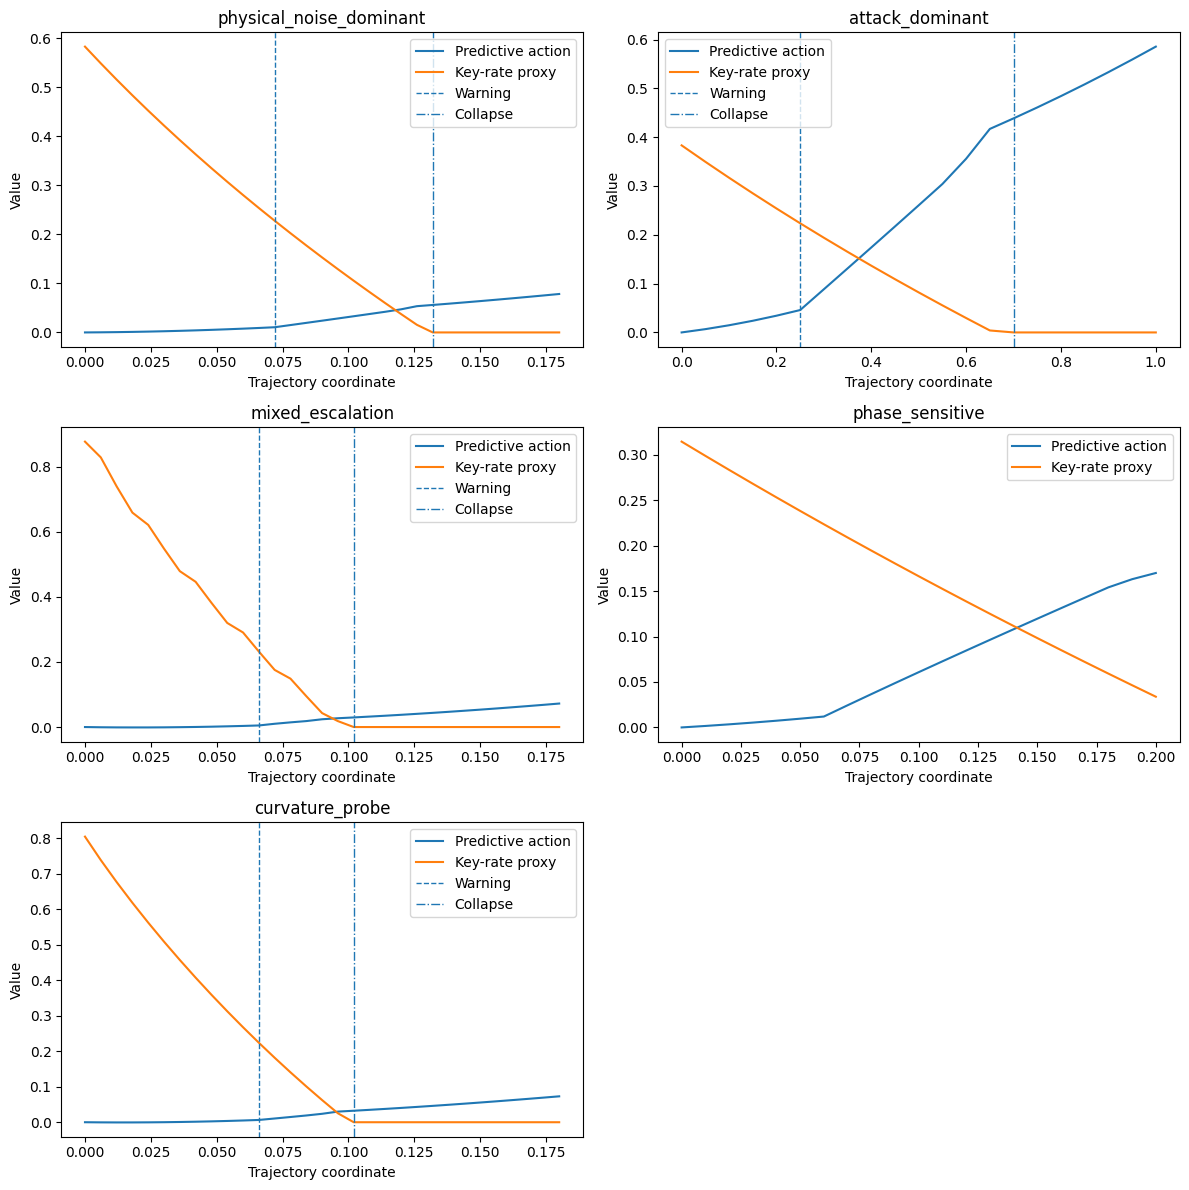

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, name in zip(axes, trajectory_names):
    sub = traj_df[traj_df["trajectory_name"] == name].copy().reset_index(drop=True)
    ew = early_warning_df[early_warning_df["trajectory_name"] == name].iloc[0]

    ax.plot(sub["path_coordinate"], sub["action_predictive"], label="Predictive action")
    ax.plot(sub["path_coordinate"], sub["key_rate"], label="Key-rate proxy")

    if pd.notna(ew["warning_coordinate"]):
        ax.axvline(ew["warning_coordinate"], linestyle="--", linewidth=1.0, label="Warning")
    if pd.notna(ew["collapse_coordinate"]):
        ax.axvline(ew["collapse_coordinate"], linestyle="-.", linewidth=1.0, label="Collapse")

    ax.set_title(name)
    ax.set_xlabel("Trajectory coordinate")
    ax.set_ylabel("Value")
    ax.legend()

# hide any unused axis
for j in range(len(trajectory_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_action_early_warning_markers.png", dpi=300)
plt.show()


## 13. Stable stationarity diagnostics

The next cell computes stabilized discrete stationarity-style residuals. The derivatives are evaluated with safe path variables to avoid singular behavior.


In [15]:
stationarity_rows = []

for name in trajectory_names:
    sub = traj_df[traj_df["trajectory_name"] == name].copy().reset_index(drop=True)

    q = np.where(np.abs(sub["qber"].values) < EPS, EPS, sub["qber"].values)
    k = np.where(np.abs(sub["key_rate"].values) < EPS, EPS, sub["key_rate"].values)
    path = np.asarray(sub["path_coordinate"].values, dtype=float)
    for i in range(1, len(path)):
        if abs(path[i] - path[i-1]) < EPS:
            path[i] = path[i-1] + EPS

    L = sub["lagrangian_predictive"].values

    dL_dq = safe_gradient(L, q)
    dL_dk = safe_gradient(L, k)
    d2L_path = safe_gradient(safe_gradient(L, path), path)

    residual = np.abs(np.nan_to_num(dL_dq)) + np.abs(np.nan_to_num(dL_dk))
    residual = np.nan_to_num(residual, nan=0.0, posinf=0.0, neginf=0.0)

    sub["dL_dq"] = np.nan_to_num(dL_dq, nan=0.0, posinf=0.0, neginf=0.0)
    sub["dL_dk"] = np.nan_to_num(dL_dk, nan=0.0, posinf=0.0, neginf=0.0)
    sub["d2L_path"] = np.nan_to_num(d2L_path, nan=0.0, posinf=0.0, neginf=0.0)
    sub["stationarity_residual"] = residual

    stationarity_rows.append(sub)

stationarity_df = pd.concat(stationarity_rows, ignore_index=True)
stationarity_df.to_csv(TAB_DIR / "table_stationarity_diagnostics.csv", index=False)

display(stationarity_df[[
    "trajectory_name", "path_coordinate", "qber", "key_rate",
    "lagrangian_predictive", "dL_dq", "dL_dk", "d2L_path", "stationarity_residual"
]].head(12))


C:\Users\amala\anaconda3\envs\deepfake\lib\site-packages\numpy\lib\_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Users\amala\anaconda3\envs\deepfake\lib\site-packages\numpy\lib\_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Users\amala\anaconda3\envs\deepfake\lib\site-packages\numpy\lib\_function_base_impl.py:1298: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
C:\Users\amala\anaconda3\envs\deepfake\lib\site-packages\numpy\lib\_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Users\amala\anaconda3\envs\deepfake\lib\site-packages\numpy\lib\_function_base_impl.py:1292: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Users\amala\anaconda3\envs\deepfake\

,trajectory_name,path_coordinate,qber,key_rate,lagrangian_predictive,dL_dq,dL_dk,d2L_path,stationarity_residual
0,physical_noise_dominant,0.000,0.032880,0.582729,0.020186,5.830419,-0.607272,-5.409397,6.437691
1,physical_noise_dominant,0.006,0.036432,0.548626,0.040896,5.775594,-0.610977,-7.882285,6.386571
2,physical_noise_dominant,0.012,0.039984,0.515562,0.061216,5.670643,-0.618162,-9.929576,6.288805
3,physical_noise_dominant,0.018,0.043536,0.483448,0.081180,5.574319,-0.625155,-9.145796,6.199474
4,physical_noise_dominant,0.024,0.047088,0.452208,0.100816,5.485255,-0.631990,-8.481992,6.117245
5,physical_noise_dominant,0.030,0.050640,0.421781,0.120148,5.402386,-0.638696,-7.912537,6.041082
6,physical_noise_dominant,0.036,0.054192,0.392112,0.139195,5.324866,-0.645295,-7.418640,5.970160
7,physical_noise_dominant,0.042,0.057744,0.363153,0.157975,5.252009,-0.651806,-6.986200,5.903814
8,physical_noise_dominant,0.048,0.061296,0.334864,0.176505,5.183254,-0.658245,-6.604429,5.841499
9,physical_noise_dominant,0.054,0.064848,0.307207,0.194797,5.118135,-0.664627,-6.264929,5.782762


## 14. Plot: stationarity residuals

The next cell visualizes the stabilized stationarity residuals. Peaks indicate locations where the trajectory departs from local regularity in the variational landscape.


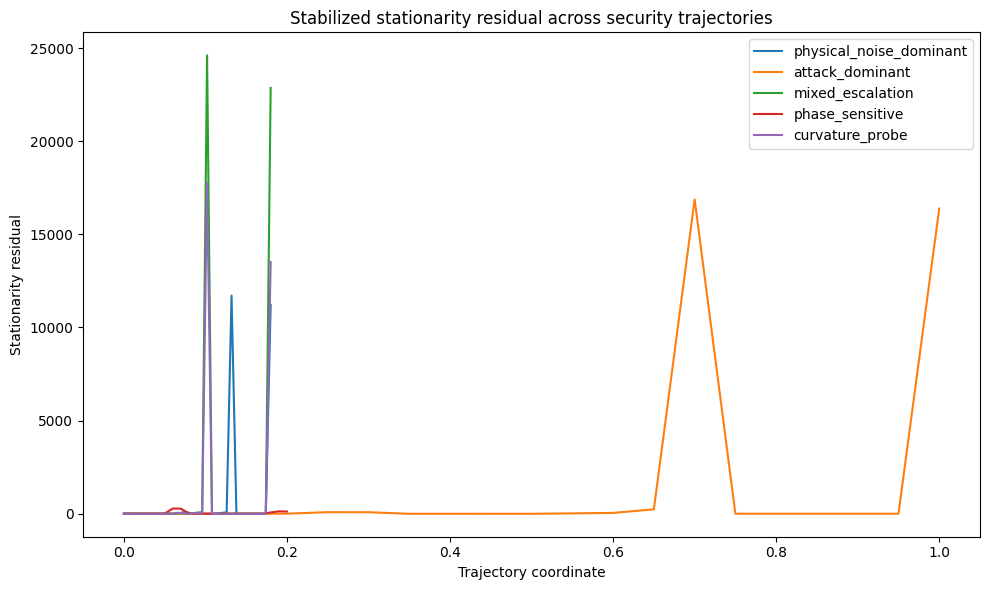

In [16]:
plt.figure(figsize=(10, 6))
for name in trajectory_names:
    sub = stationarity_df[stationarity_df["trajectory_name"] == name]
    plt.plot(sub["path_coordinate"], sub["stationarity_residual"], label=name)
plt.xlabel("Trajectory coordinate")
plt.ylabel("Stationarity residual")
plt.title("Stabilized stationarity residual across security trajectories")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_stationarity_residuals.png", dpi=300)
plt.show()


## 15. Trajectory ranking by action, acceleration, and anticipation

The next cell ranks the trajectories using multiple variational indicators.


In [17]:
ranking_df = trajectory_summary.merge(early_warning_df, on="trajectory_name", how="left")
ranking_df["action_rank"] = ranking_df["final_predictive_action"].rank(ascending=False, method="dense")
ranking_df["acceleration_rank"] = ranking_df["max_action_acceleration"].rank(ascending=False, method="dense")
ranking_df["anticipation_rank"] = ranking_df["anticipation_pct"].rank(ascending=False, method="dense")

ranking_df.to_csv(TAB_DIR / "table_trajectory_ranking.csv", index=False)
display(ranking_df.sort_values(["anticipation_rank", "action_rank", "acceleration_rank"]))


,trajectory_name,has_collapse,collapse_coordinate_x,action_at_collapse,final_predictive_action,max_instability_potential,max_action_acceleration,warning_coordinate,collapse_coordinate_y,anticipation_pct,action_rank,acceleration_rank,anticipation_rank
1,attack_dominant,1,0.700,0.438441,0.585430,0.806681,6.334570,0.250,0.700,64.285714,1.0,5.0,1.0
0,physical_noise_dominant,1,0.132,0.056017,0.078369,0.666001,41.818206,0.072,0.132,45.454545,3.0,3.0,2.0
4,curvature_probe,1,0.102,0.032389,0.073001,0.648519,38.408274,0.066,0.102,35.294118,4.0,4.0,3.0
2,mixed_escalation,1,0.102,0.029500,0.072193,0.585518,47.701127,0.066,0.102,35.294118,5.0,2.0,3.0
3,phase_sensitive,0,NaN,NaN,0.169951,0.986730,50.123979,NaN,NaN,NaN,2.0,1.0,NaN


## 16. Comparative bar plot of action and action acceleration

The next cell summarizes the action intensity and maximum action acceleration across trajectories.


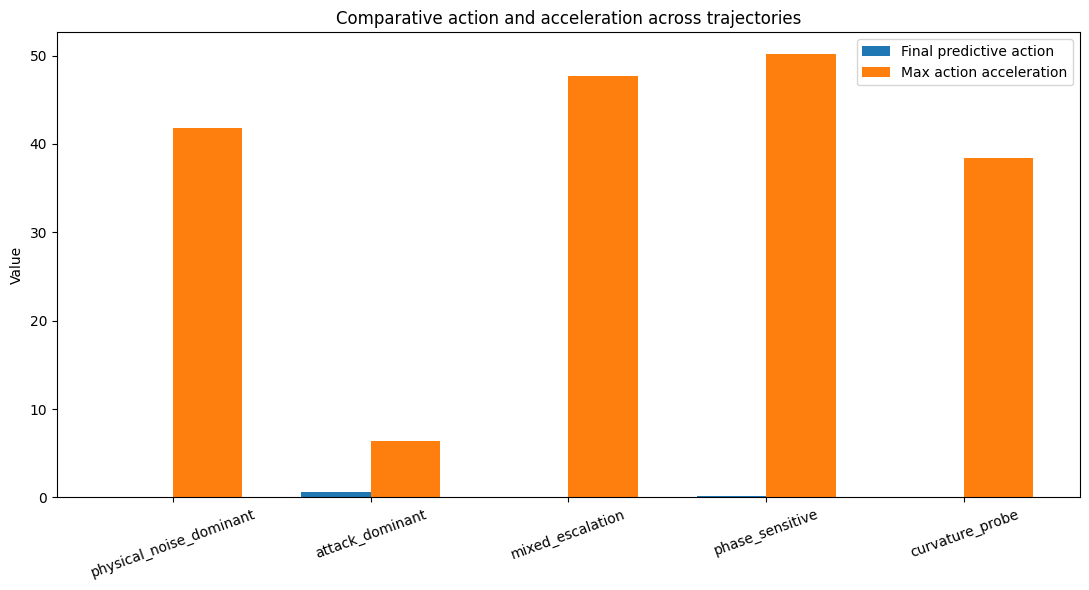

In [18]:
plot_df = trajectory_summary.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, plot_df["final_predictive_action"], width=width, label="Final predictive action")
plt.bar(x + width/2, plot_df["max_action_acceleration"], width=width, label="Max action acceleration")
plt.xticks(x, plot_df["trajectory_name"], rotation=20)
plt.ylabel("Value")
plt.title("Comparative action and acceleration across trajectories")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_action_comparison_bar.png", dpi=300)
plt.show()


## 17. Global 2D predictive Lagrangian landscape

The next cell creates a 2D landscape over depolarizing noise and attack intensity at fixed phase noise. This is a pointwise snapshot of the variational landscape underlying the action-based interpretation.


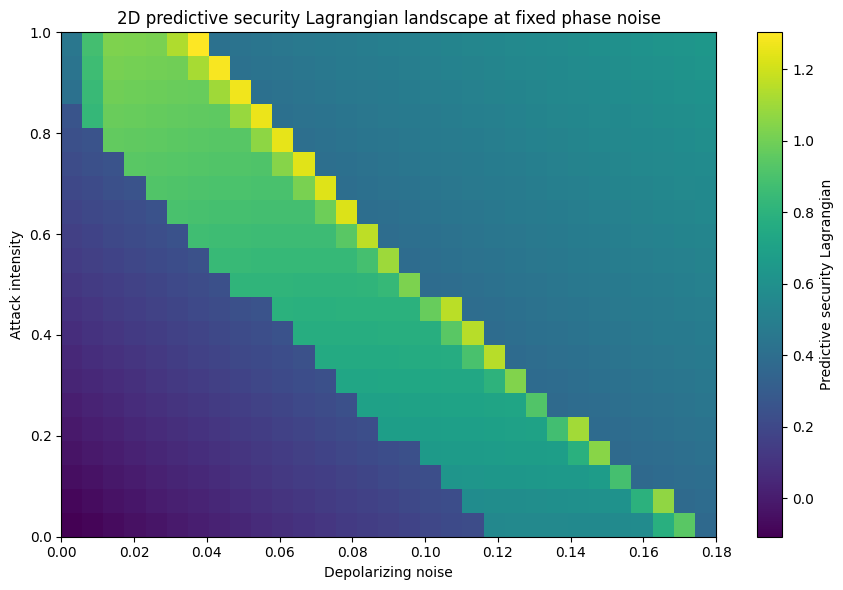

In [19]:
fixed_phase_2d = 0.06
map_rows = []

for a in attack_grid:
    local_rows = []
    for d in depolarizing_grid:
        q = qber_proxy(d, fixed_phase_2d, a)
        h = binary_entropy(q)
        k = key_rate_proxy(q)
        loss = channel_loss_proxy(d, fixed_phase_2d)
        attack_score = clip01(0.55 * a + 0.45 * (q / max(df["qber"].max(), EPS)))
        local_rows.append([d, a, q, h, k, loss, attack_score])

    local_df = pd.DataFrame(local_rows, columns=[
        "depolarizing_noise", "attack_intensity", "qber", "entropy",
        "key_rate", "channel_loss", "ai_attack_likelihood"
    ])

    local_df["lagrangian_base"] = security_lagrangian(
        entropy_term=local_df["entropy"].values,
        channel_term=local_df["channel_loss"].values,
        attack_term=local_df["ai_attack_likelihood"].values,
        capacity_term=local_df["key_rate"].values,
        instability_term=0.0
    )

    local_df["var_k_raw"] = rolling_window_variance(local_df["key_rate"].values, window=5)
    local_df["neg_slope_raw"] = backward_negative_slope(local_df["key_rate"].values, local_df["depolarizing_noise"].values)
    base_curvature = safe_gradient(
        safe_gradient(local_df["lagrangian_base"].values, local_df["depolarizing_noise"].values),
        local_df["depolarizing_noise"].values
    )

    local_df["var_k_norm"] = normalize_series(local_df["var_k_raw"].values)
    local_df["neg_slope_norm"] = normalize_series(local_df["neg_slope_raw"].values)
    local_df["curvature_norm"] = normalize_series(np.abs(base_curvature))
    local_df["precritical_gate"] = precritical_gate(local_df["qber"].values, local_df["key_rate"].values)

    local_df["critical_instability_potential"] = local_df["precritical_gate"] * (
        ETA_VAR * local_df["var_k_norm"]
        + ZETA_SLOPE * local_df["neg_slope_norm"]
        + THETA_CURV * local_df["curvature_norm"]
    )

    local_df["lagrangian_predictive"] = security_lagrangian(
        entropy_term=local_df["entropy"].values,
        channel_term=local_df["channel_loss"].values,
        attack_term=local_df["ai_attack_likelihood"].values,
        capacity_term=local_df["key_rate"].values,
        instability_term=local_df["critical_instability_potential"].values
    )
    map_rows.append(local_df)

map_df = pd.concat(map_rows, ignore_index=True)
map_df.to_csv(TAB_DIR / "table_lagrangian_2d_map.csv", index=False)

pivot_L = map_df.pivot(index="attack_intensity", columns="depolarizing_noise", values="lagrangian_predictive")

plt.figure(figsize=(9, 6))
plt.imshow(
    pivot_L.values,
    aspect="auto",
    origin="lower",
    extent=[
        pivot_L.columns.min(), pivot_L.columns.max(),
        pivot_L.index.min(), pivot_L.index.max()
    ]
)
plt.colorbar(label="Predictive security Lagrangian")
plt.xlabel("Depolarizing noise")
plt.ylabel("Attack intensity")
plt.title("2D predictive security Lagrangian landscape at fixed phase noise")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_lagrangian_2d_landscape.png", dpi=300)
plt.show()


## 18. Outputs summary writer

The next cell writes a compact quantitative summary in text and JSON format.

In [21]:
mean_anticipation = float(early_warning_df["anticipation_pct"].replace([np.inf, -np.inf], np.nan).dropna().mean()) if early_warning_df["anticipation_pct"].notna().any() else None
max_final_action = float(trajectory_summary["final_predictive_action"].max())
max_stationarity = float(stationarity_df["stationarity_residual"].max())
n_collapsing = int(trajectory_summary["has_collapse"].sum())
mean_acceleration = float(trajectory_summary["max_action_acceleration"].mean())

results = {
    "project_name": PROJECT_NAME,
    "n_total_states": int(len(df)),
    "n_total_trajectory_points": int(len(traj_df)),
    "trajectory_names": trajectory_names,
    "n_collapsing_trajectories": n_collapsing,
    "mean_action_anticipation_pct": mean_anticipation,
    "max_final_predictive_action": max_final_action,
    "max_stationarity_residual": max_stationarity,
    "mean_max_action_acceleration": mean_acceleration,
    "figure_files": sorted([p.name for p in FIG_DIR.glob("*.png")]),
    "table_files": sorted([p.name for p in TAB_DIR.glob("*.csv")]),
}

summary_lines = [
    "QSFE Complete",
    "=" * 57,
    f"Project: {results['project_name']}",
    f"Number of global states: {results['n_total_states']}",
    f"Number of trajectory points: {results['n_total_trajectory_points']}",
    "",
    "Trajectory set:",
] + [f"- {name}" for name in results["trajectory_names"]] + [
    "",
    f"Number of collapsing trajectories: {results['n_collapsing_trajectories']}",
    f"Mean action-based anticipation (%): {results['mean_action_anticipation_pct']}",
    f"Maximum final predictive action: {results['max_final_predictive_action']:.6f}",
    f"Maximum stationarity residual: {results['max_stationarity_residual']:.6f}",
    f"Mean maximum action acceleration: {results['mean_max_action_acceleration']:.6f}",
    "",
    "Generated figures:",
] + [f"  * {x}" for x in results["figure_files"]] + [
    "",
    "Generated tables:",
] + [f"  * {x}" for x in results["table_files"]]

summary_text = "\n".join(summary_lines)

summary_txt_path = OTH_DIR / "outputs_summary.txt"
summary_json_path = OTH_DIR / "outputs_summary.json"

with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(summary_text)
print("\nSaved files:")
print(summary_txt_path)
print(summary_json_path)


QSFE Complete
Project: QSFE
Number of global states: 13671
Number of trajectory points: 135

Trajectory set:
- physical_noise_dominant
- attack_dominant
- mixed_escalation
- phase_sensitive
- curvature_probe

Number of collapsing trajectories: 4
Mean action-based anticipation (%): 45.08212375859435
Maximum final predictive action: 0.585430
Maximum stationarity residual: 24611.420823
Mean maximum action acceleration: 36.877231

Generated figures:
  * fig_action_accumulation.png
  * fig_action_comparison_bar.png
  * fig_action_early_warning_markers.png
  * fig_instability_and_action_acceleration.png
  * fig_lagrangian_2d_landscape.png
  * fig_lagrangian_profiles.png
  * fig_normalized_action.png
  * fig_stationarity_residuals.png

Generated tables:
  * table_action_early_warning.csv
  * table_all_trajectories.csv
  * table_lagrangian_2d_map.csv
  * table_stationarity_diagnostics.csv
  * table_summary_statistics.csv
  * table_trajectory_ranking.csv
  * table_trajectory_summary.csv

Saved 